# Sepsis (Camargo) — Old vs Improved

Single-source comparison: runs Camargo-style suffix sampling for both checkpoints (skipping any side that
already has chunked outputs), evaluates an **activity-only** metric set (Camargo doesn't predict time),
then plots them side by side.

**Pair:** `camargo/sepsis` &nbsp;·&nbsp; **Activity key:** `concept:name` &nbsp;·&nbsp; **Samples/case:** `100`

> Sampling uses ``ensure_sampled_camargo`` from ``_shared/camargo_sampling.py`` —
> argmax for ``mean_prediction`` and softmax-temperature draws for the
> ``predicted_suffixes``. Side-channel features and time are carried forward
> from the last observed event during autoregressive decoding (Camargo paper
> convention); the metric set drops every time metric since the model has no
> time head.

## How to run

1. Confirm the paths in the parameter cell point at the right Camargo checkpoints + test pickles.
2. Execute top-to-bottom. Sampling is skipped automatically if `SAMPLED_DIR_*` already contains `results_part_*.pkl`.
3. The bottom cells (table + overlay plot) tolerate either side being `None` — useful while one side is still being trained.


## Parameters

In [1]:
# === PARAMETER CELL ===
# Tweak paths and knobs here. Everything below should run unchanged.
from pathlib import Path

PAIR_DIR = Path('.').resolve()   # the dir containing this notebook

# --- model checkpoints (None = side not yet trained / placeholder) ---
MODEL_OLD_PATH      = PAIR_DIR / 'old/Training/pkl/Sepsis_camargo_sharedcat_ngram5.pkl'
MODEL_IMPROVED_PATH = PAIR_DIR / 'improved/Training/pkl/Sepsis_camargo_sharedcat_allfeat_ngram5.pkl'

# --- encoded test pickles (must match what each checkpoint was trained on) ---
TEST_PKL_OLD      = PAIR_DIR / 'old/Loader/pkl/Sepsis_all_5_roles_test.pkl'
TEST_PKL_IMPROVED = PAIR_DIR / 'improved/Loader/pkl/Sepsis_all_5_allfeat_test.pkl'

# --- where the chunked sampling results land (also where batch_evaluate reads from) ---
SAMPLED_DIR_OLD      = PAIR_DIR / 'evaluation_results/old'
SAMPLED_DIR_IMPROVED = PAIR_DIR / 'evaluation_results/improved'

# --- comparison output ---
COMPARISON_PKL = PAIR_DIR / 'sepsis_old_vs_improved.pkl'
CAPTION        = 'Sepsis (Camargo)'

# --- Camargo model specs (cat/num feature indices into the test pickle, +
#     model class + ngram window). These mirror the camargo block in
#     src/interpretability/config/sepsis_config.py. ---
SPEC_OLD = dict(
    model_class='SharedCat_LSTM',
    cat_indices=(0, 1),                    # concept:name, org:group
    num_indices=(0,),                      # case_elapsed_time
    activity_feature='concept:name',
    ngram_size=5,
)
SPEC_IMPROVED = dict(
    model_class='SharedCat_LSTM',
    cat_indices=tuple(range(26)),          # all categoricals
    num_indices=tuple(range(8)),           # all numericals
    activity_feature='concept:name',
    ngram_size=5,
)

# --- sampling knobs (SamplingConfig kwargs) ---
CONCEPT_NAME        = 'concept:name'
ALL_CAT             = None
ALL_NUM             = None
GROWING_NUM_VALUES  = ['case_elapsed_time']
NUM_PROCESSES       = 16
SAMPLES_PER_CASE    = 100
SAVE_EVERY          = 50
RANDOM_ORDER        = False
USE_VARIANCE_CAT    = True
USE_VARIANCE_NUM    = True
SAMPLE_ARGMAX       = False
SAMPLING_TEMPERATURE = 1.0   # softmax temperature for stochastic decoding

# --- metric knobs (activity-only metric set; time metrics dropped for Camargo) ---
ACTIVITY_KEY      = 'concept:name'
EVENT_LABEL_LIST  = ['ER Registration', 'Leucocytes', 'CRP', 'LacticAcid', 'ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'IV Antibiotics', 'Admission NC', 'Release A', 'Return ER', 'Admission IC', 'Release B', 'Release C', 'Release D', 'Release E']


## Setup

In [2]:
import sys, importlib
from pathlib import Path

# Reach `src/` so `model.*`, `src.evaluation_metrics.*` resolve.
_REPO_ROOT = Path('.').resolve()
while not (_REPO_ROOT / 'src').is_dir() and _REPO_ROOT != _REPO_ROOT.parent:
    _REPO_ROOT = _REPO_ROOT.parent
for p in (
    str(_REPO_ROOT),
    str(_REPO_ROOT / 'src'),
    str(_REPO_ROOT / 'src' / 'reimplemented_comparable_approaches' / 'camargo_LSTM_suffix_pred'),
):
    if p not in sys.path:
        sys.path.insert(0, p)

# Reach the _shared helper module.
_SHARED = _REPO_ROOT / 'src' / 'interpretability' / 'improved_pipeline' / '_shared'
if str(_SHARED) not in sys.path:
    sys.path.insert(0, str(_SHARED))

import comparison_helpers
importlib.reload(comparison_helpers)
from comparison_helpers import (
    SamplingConfig, evaluate_dir, comparison_table, plot_overlay, save_results,
)

import camargo_sampling
importlib.reload(camargo_sampling)
from camargo_sampling import (
    ensure_sampled_camargo, default_metric_set_camargo, CamargoSpec,
)


## MC suffix sampling (skipped per side if chunks already exist)

In [3]:
sampling_cfg = SamplingConfig(
    concept_name=CONCEPT_NAME,
    growing_num_values=GROWING_NUM_VALUES,
    all_cat=ALL_CAT,
    all_num=ALL_NUM,
    num_processes=NUM_PROCESSES,
    samples_per_case=SAMPLES_PER_CASE,
    sample_argmax=SAMPLE_ARGMAX,
    use_variance_cat=USE_VARIANCE_CAT,
    use_variance_num=USE_VARIANCE_NUM,
    random_order=RANDOM_ORDER,
    save_every=SAVE_EVERY,
)

if MODEL_OLD_PATH and TEST_PKL_OLD:
    ensure_sampled_camargo(
        MODEL_OLD_PATH, TEST_PKL_OLD, SAMPLED_DIR_OLD, sampling_cfg,
        spec=CamargoSpec(**SPEC_OLD),
        sampling_temperature=SAMPLING_TEMPERATURE,
    )
else:
    print('[skip] OLD side: missing MODEL_OLD_PATH or TEST_PKL_OLD')

if MODEL_IMPROVED_PATH and TEST_PKL_IMPROVED:
    ensure_sampled_camargo(
        MODEL_IMPROVED_PATH, TEST_PKL_IMPROVED, SAMPLED_DIR_IMPROVED, sampling_cfg,
        spec=CamargoSpec(**SPEC_IMPROVED),
        sampling_temperature=SAMPLING_TEMPERATURE,
    )
else:
    print('[skip] IMPROVED side: missing MODEL_IMPROVED_PATH or TEST_PKL_IMPROVED')


[sample-camargo] /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/improved_pipeline/camargo/sepsis/evaluation_results/old already has 53 chunks — skipping (force=True to redo).
[sample-camargo] /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/improved_pipeline/camargo/sepsis/evaluation_results/improved already has 53 chunks — skipping (force=True to redo).


## Build metric set

In [4]:
metrics = default_metric_set_camargo(
    activity_key=ACTIVITY_KEY,
    event_label_list=EVENT_LABEL_LIST,
)
print(f'metric set has {len(metrics)} entries (activity-only — Camargo has no time head)')


metric set has 12 entries (activity-only — Camargo has no time head)


## Evaluate sampled outputs

In [5]:
res_old, counts_old = (None, None)
res_improved, counts_improved = (None, None)

if SAMPLED_DIR_OLD.is_dir() and any(SAMPLED_DIR_OLD.glob('results_part_*.pkl')):
    res_old, counts_old = evaluate_dir(SAMPLED_DIR_OLD, metrics)
else:
    print('[skip] OLD eval: no chunks under', SAMPLED_DIR_OLD)

if SAMPLED_DIR_IMPROVED.is_dir() and any(SAMPLED_DIR_IMPROVED.glob('results_part_*.pkl')):
    res_improved, counts_improved = evaluate_dir(SAMPLED_DIR_IMPROVED, metrics)
else:
    print('[skip] IMPROVED eval: no chunks under', SAMPLED_DIR_IMPROVED)


[eval] batch_evaluate(/Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/improved_pipeline/camargo/sepsis/evaluation_results/old)
Loaded: results_part_1000.pkl
Loaded: results_part_1050.pkl
Loaded: results_part_050.pkl
Loaded: results_part_100.pkl
Loaded: results_part_1100.pkl
Loaded: results_part_1150.pkl
Loaded: results_part_1250.pkl
Loaded: results_part_1200.pkl
Loaded: results_part_1350.pkl
Loaded: results_part_1400.pkl
Loaded: results_part_1450.pkl
Loaded: results_part_1300.pkl
Loaded: results_part_1500.pkl
Loaded: results_part_150.pkl
Loaded: results_part_1600.pkl
Loaded: results_part_1550.pkl
Loaded: results_part_1650.pkl
Loaded: results_part_1750.pkl
Loaded: results_part_1700.pkl
Loaded: results_part_1800.pkl
Loaded: results_part_1900.pkl
Loaded: results_part_1850.pkl
Loaded: results_part_1950.pkl
Loaded: results_part_200.pkl
Loaded: results_part_2000.pkl
Loaded: results_part_2050.pkl
Loaded: results_part_2150.pkl
Loaded: 

## Side-by-side metric table

In [6]:
import pandas as pd
df = comparison_table(res_old, res_improved)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
df


,metric,kind,old,improved,delta,delta_pct,lower_is_better
0,NormalizedDamerauLevenshteinMeanVar_activity,mean,0.1722,0.1836,0.0114,6.5953,True
1,NormalizedDamerauLevenshteinMeanVar_activity,prob,0.2061,0.2062,0.0001,0.0391,True
2,SuffixCountInterval_50,mean,0.0000,0.0000,NaN,NaN,False
3,SuffixCountInterval_50,prob,0.2776,0.2024,-0.0753,-27.1093,False
4,SuffixCountInterval_75,mean,0.0000,0.0000,NaN,NaN,False
5,SuffixCountInterval_75,prob,0.4259,0.3648,-0.0611,-14.3372,False
6,SuffixCountInterval_90,mean,0.0000,0.0000,NaN,NaN,False
7,SuffixCountInterval_90,prob,0.6463,0.5557,-0.0906,-14.0226,False
8,SuffixCountInterval_95,mean,0.0000,0.0000,NaN,NaN,False
9,SuffixCountInterval_95,prob,0.7561,0.6586,-0.0975,-12.8999,False


## Paper-style summary (next-event accuracy + DL similarity)

Two activity-only measures, matching what the original papers report on this
dataset. Computed directly from the saved sampling chunks:

- **Next-event accuracy** — fraction of prefixes where the first activity in the
  argmax (`mean`) prediction equals the actual next activity. Higher is better.
- **DL similarity (suffix, probabilistic)** — average normalized Damerau-Levenshtein
  similarity (`1 - distance`) between each ground-truth suffix and the 100 stochastic
  suffix samples drawn for that prefix, then averaged over prefixes. Higher is better.

The argmax (`mean`) DL similarity is also shown for reference, but it's pulled down
when the argmax decoder rarely emits EOS and produces over-long suffixes — the
probabilistic figure is the one to compare against the paper.


In [7]:
# === Paper-style summary: next-event accuracy + DL similarity ===
# Reads saved chunks directly so this cell is independent of the metric set above.
# Auto-uses ACTIVITY_KEY / SAMPLED_DIR_OLD / SAMPLED_DIR_IMPROVED from the
# parameter cell, so the same cell works for every (pair, dataset) notebook.
import pickle, glob
from src.evaluation_metrics.metrics import NormalizedDamerauLevenshteinDistanceMean

ATTR = ACTIVITY_KEY
# NOTE: this class returns SIMILARITY (1 - normalized DL distance), not distance,
# despite the variable being named "mean_distance" in metrics.py:564. Higher is better.
dl_metric = NormalizedDamerauLevenshteinDistanceMean(ATTR)

def _eval_dir(chunk_dir):
    n_total, n_correct = 0, 0
    sim_argmax_sum, sim_proba_sum = 0.0, 0.0
    for f in sorted(glob.glob(f"{chunk_dir}/results_part_*.pkl")):
        with open(f, "rb") as fh:
            chunk = pickle.load(fh)
        for _, (prefix, suffix, mean_pred, prob_preds) in chunk.items():
            if not suffix or not mean_pred:
                continue
            n_total += 1
            n_correct += int(mean_pred[0][ATTR] == suffix[0][ATTR])
            r = dl_metric.evaluate(prefix, suffix, mean_pred, prob_preds)
            sim_argmax_sum += r["mean"]
            sim_proba_sum  += r["prob"]
    if n_total == 0:
        return None
    return {
        "n_prefixes":           n_total,
        "next_event_accuracy":  n_correct / n_total,
        "dl_similarity_proba":  sim_proba_sum  / n_total,
        "dl_similarity_argmax": sim_argmax_sum / n_total,
    }

summary = {}
if SAMPLED_DIR_OLD.is_dir():
    s = _eval_dir(SAMPLED_DIR_OLD)
    if s: summary["old"] = s
if SAMPLED_DIR_IMPROVED.is_dir():
    s = _eval_dir(SAMPLED_DIR_IMPROVED)
    if s: summary["improved"] = s

import pandas as pd
rows = [
    {
        "variant": label,
        "n_prefixes":           summary[label]["n_prefixes"],
        "next_event_accuracy":  summary[label]["next_event_accuracy"],
        "dl_similarity_proba":  summary[label]["dl_similarity_proba"],
        "dl_similarity_argmax": summary[label]["dl_similarity_argmax"],
    }
    for label in ("old", "improved") if label in summary
]
paper_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
paper_df


,variant,n_prefixes,next_event_accuracy,dl_similarity_proba,dl_similarity_argmax
0,old,2560,0.6605,0.2037,0.1752
1,improved,2547,0.6463,0.2042,0.1877


## Overlay plots

[plot] OLD: Sepsis (Camargo)


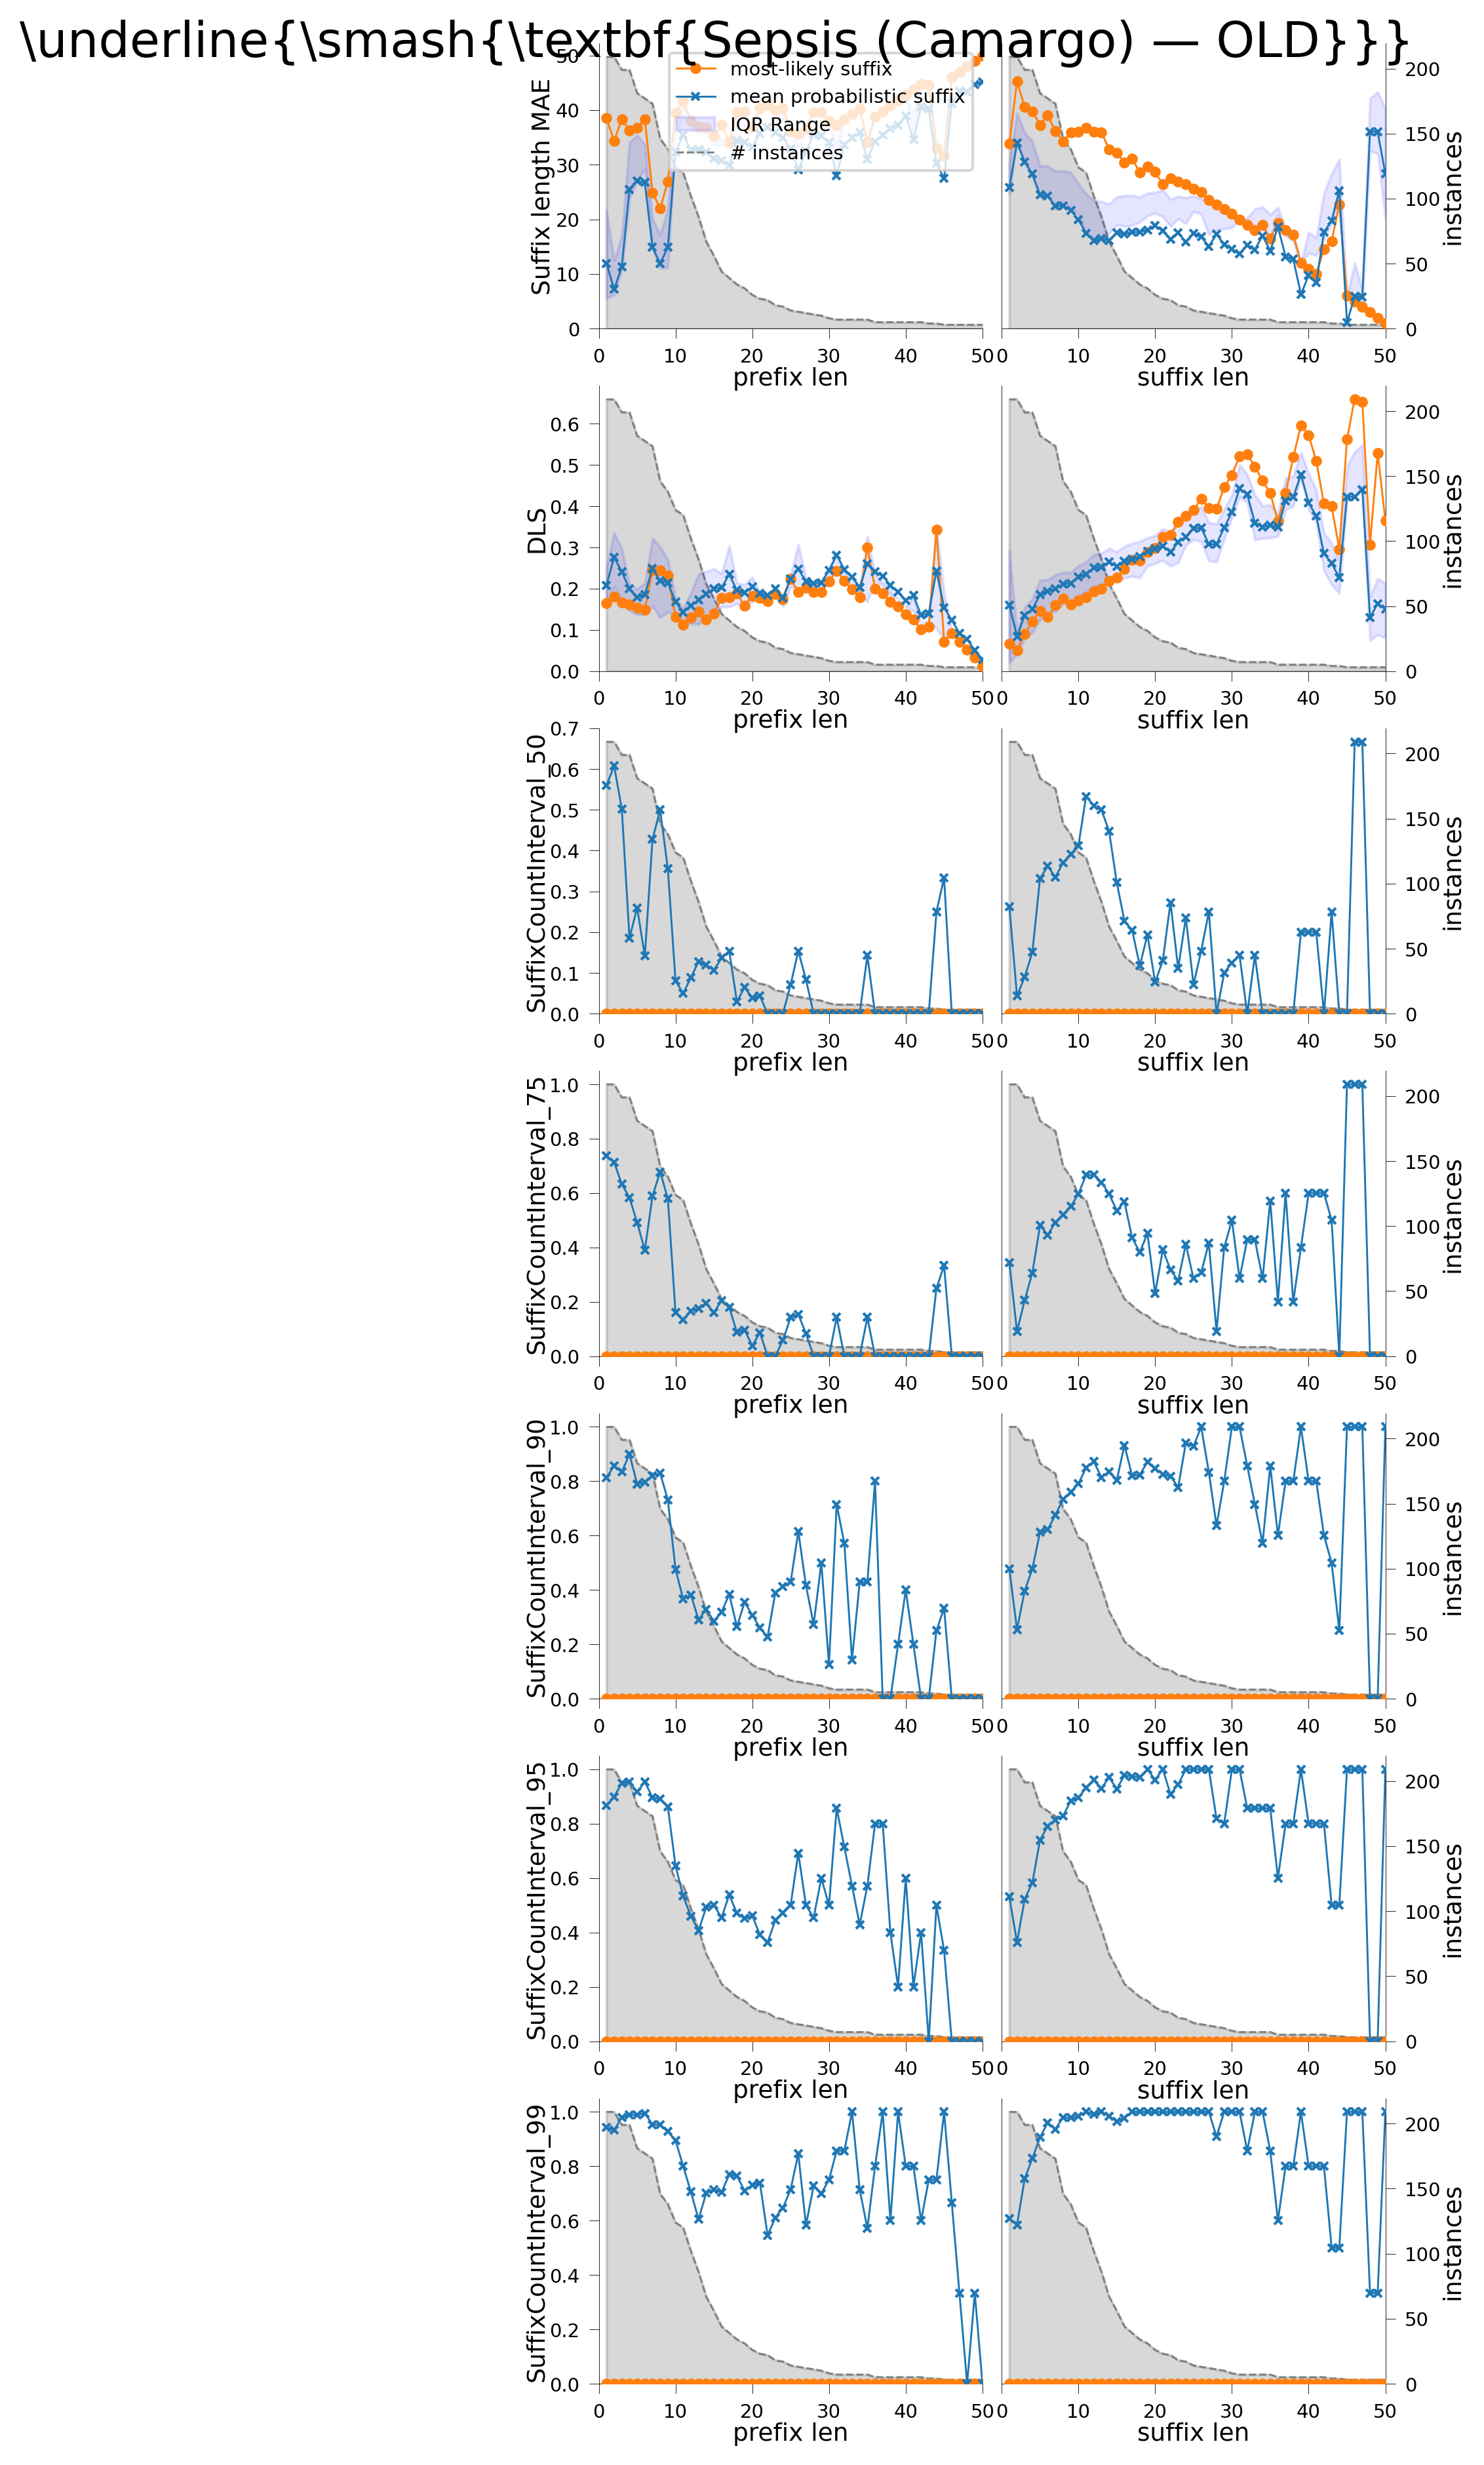

[plot] IMPROVED: Sepsis (Camargo)


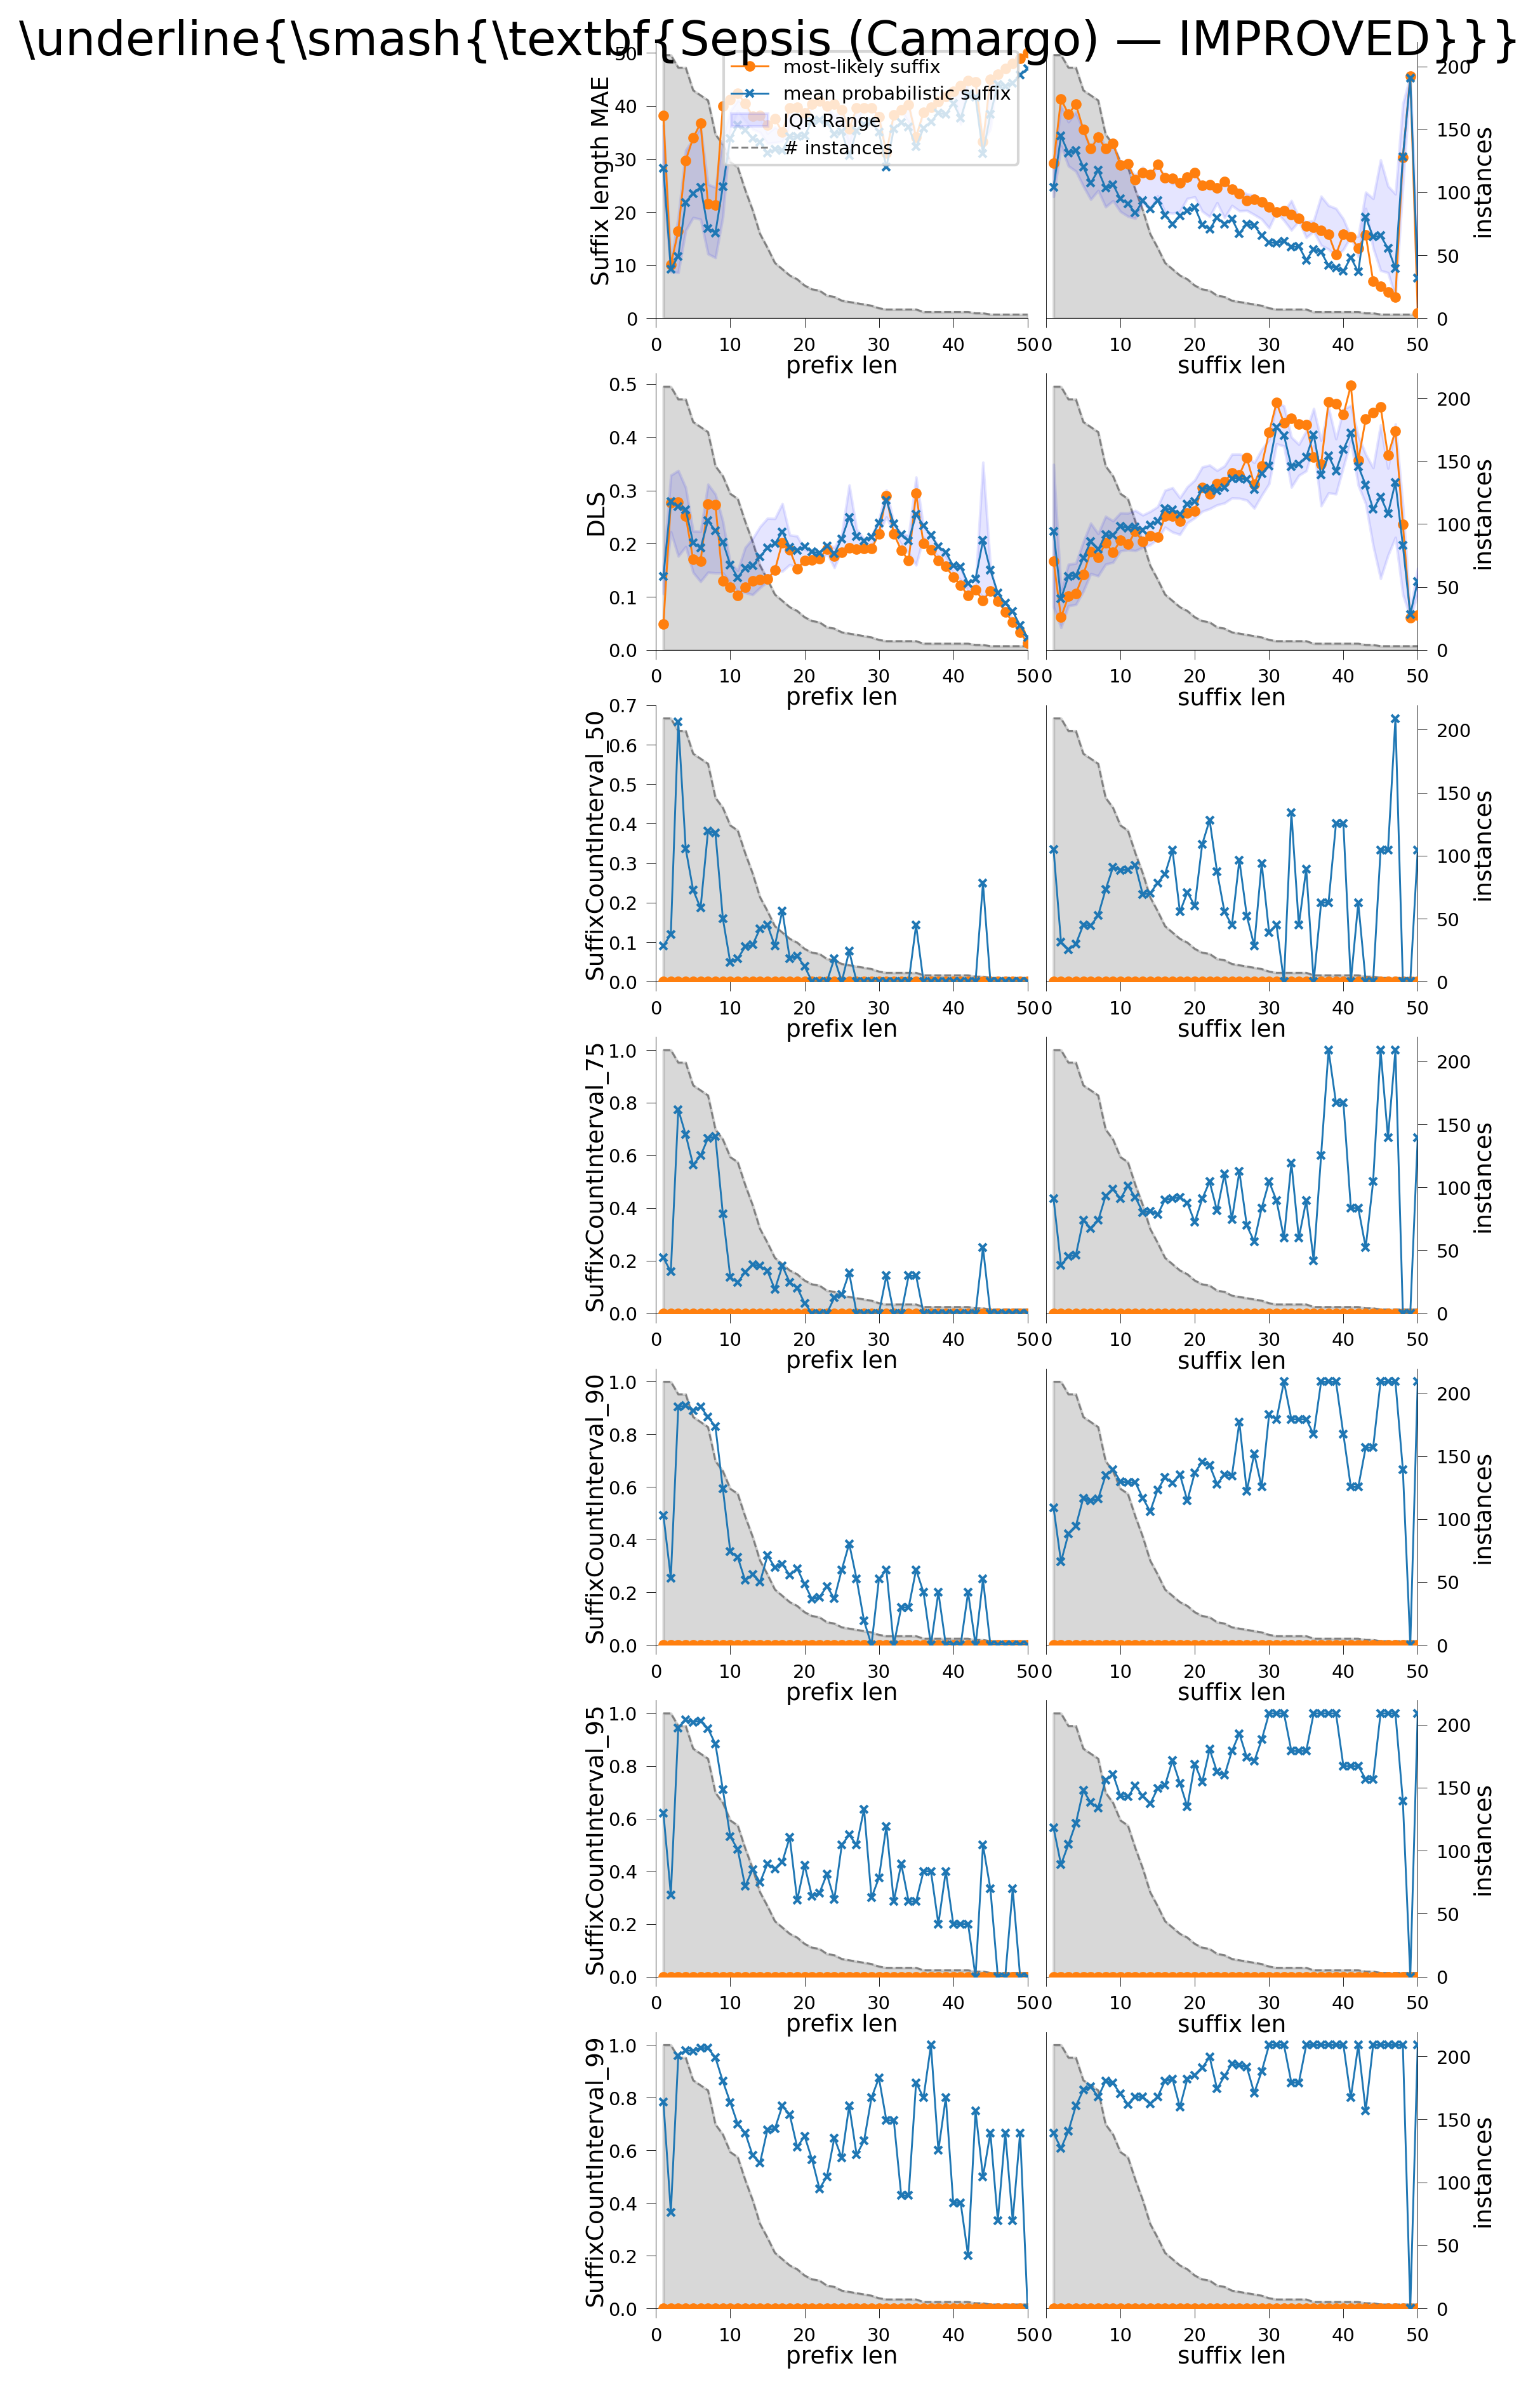

In [8]:
plot_overlay(res_old, res_improved, counts_old, counts_improved, caption=CAPTION, pgf=False)


## Save comparison pickle

In [9]:
save_results(
    COMPARISON_PKL,
    res_old=res_old, counts_old=counts_old,
    res_improved=res_improved, counts_improved=counts_improved,
    config_old=sampling_cfg, config_improved=sampling_cfg,
)


[save] wrote /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/improved_pipeline/camargo/sepsis/sepsis_old_vs_improved.pkl


## Notes

- The comparison pickle written in the last cell holds both `(res_raw, counts)` pairs and the sampling configs that produced them. Re-load it later with `comparison_helpers.load_results(path)`.
- To force re-sampling, pass `force=True` into the explicit `ensure_sampled` calls (or just delete the chunked output dir).
- For dataset-specific metric tweaks, copy `default_metric_set` into a cell and edit it; the rest of the pipeline only cares that `metrics` is a `dict[str, metric]`.
